# 12.15 幾種真人語音問題，如何從零學會回應？


有人說「我的銀行 App 打不開」，我們希望助手回一個短提示，例如「先檢查網路，再重新啟動 App。」這裡想教的是聽懂幾種需求後回應，不要求把任何人說的每個字都完整抄下來。

適合這個方向的公開材料是 MInDS-14 的中文真人錄音。它收集少數銀行情境的口語需求：參與者看到意圖說明與例句，再自己說出新的問法。「意圖」在這裡就是需求種類，例如更新地址、App 出問題、卡片無法使用。本節用這三種來設計短而一般的回覆；助手沒有連接銀行帳戶，不能回報未知餘額或完成帳戶操作。

聲音怎麼接到文字回答？先沿用前面學過的 log-mel 特徵：把錄音切成短時間段，記錄各頻帶的強弱，再做固定轉換，得到按時間排列的一列數字。這一步整理聲音的變化，沒有寫出「App」兩個字，也沒有決定應回哪一句話。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

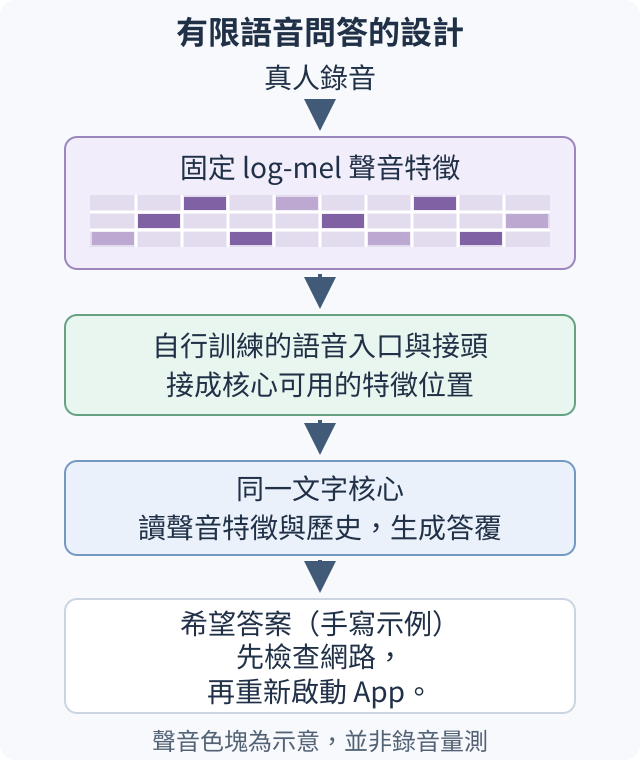

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/new-12.15-direct-audio.svg")))

接著，語音入口使用可調參數，從這列聲音數字算出需求線索。接頭把線索轉成文字核心能接收的特徵位置，也就是放進模型序列中的一組數字表示。核心讀到這些位置與對話歷史，生成中文答覆。

若要從零建立這條路，語音入口、接頭與文字核心的權重都從隨機初值開始，並需要各自的訓練安排。固定 log-mel 計算可以使用一般工具，因為它不是已經學會中文的神經模型。辨識需求與產生答覆的部分，則由這些自行訓練的元件處理。

訓練材料需要把錄音與這個任務的正確短答配在一起。MInDS-14 提供需求種類，沒有提供我們要教的客服答覆，因此答案要另外撰寫、核對。可以先讓文字核心學這幾種需求的回應，再教語音入口把對應線索送進核心；訓練時利用答案比較預測、調整參數，推論時不把標準答案一起送進去。

要看是否使用了聲音，可以保留相同背景與提問方式，改用另一類需求的錄音，檢查回覆主題是否跟著改變。還要留出原始錄音與新問法：同一段聲音的裁切或加噪版本仍是同一素材家族，不能分散後算成陌生錄音。如果所有問題都得到「請聯絡客服」，雖然語句合理，也不足以說明模型分清了這三種需求。

這和前一節的聽寫路線有不同目標。ASR 要回答「他說了哪些字」；此處直接問答要回答「這個已教過的需求，該怎麼回應」。沒有生成逐字稿，不能稱作通用 ASR；能分清三種需求，也不推出能聽懂新數字、物件名或任意中文問題。

聲音特徵經過自行訓練的入口，可以成為同一文字核心的另一種輸入。下一節只增加對話歷史，看看文字與聲音如何接續同一段需求。

<details>
<summary>公開材料、方法與例子的性質</summary>

PolyAI 的[MInDS-14 官方資料卡](https://huggingface.co/datasets/PolyAI/minds14/blob/40ce77cb32a384e4d50a568e1ec39ac804019d33/README.md)標示 CC BY 4.0，中文有 502 條，各類可用短句仍需核對；沒有公開說話者 ID，不能據此宣稱跨說話者驗收。[原論文](https://arxiv.org/abs/2104.08524)說明真人口語收集，也說明其實驗使用現成 ASR 與預訓練文字編碼器。本節借用的是合法來源與有限需求設計，不引用那些成績當從零訓練的證據。

本文沒有讀取、播放或轉寫某段公開錄音。問句、希望答案與聲音色塊都是作者設計示例。直接語音需求辨識可參考[端到端語音理解研究](https://arxiv.org/abs/1904.03670)，但該研究涉及預訓練，不能拿其結果保證本課隨機初值模型的能力。

</details>
